<a href="https://colab.research.google.com/github/hiteshkumarcsaiml25-svg/GLA-bootcamp/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1ST WEEK WORK (8-JUNE-2026 TO 10-JUNE-2026)

In [ ]:
marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks) - 1):
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")

print("Average:", average)

Class failed
Average: 43.0


In [ ]:
import pandas as pd

In [ ]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [ ]:
df.shape

(6, 5)

In [ ]:
df.head()

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [ ]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [ ]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [ ]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [ ]:
eligible_students = df[df["eligible"] == True]
eligible_students

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

   student_id  attendance_percent  assignment_score  quiz_score  \
0         101                  92                18          72   
1         102                  67                12          48   
2         103                  81                15          65   
3         104                  45                 8          30   
4         105                  74                14          55   
5         106                  88                19          80   

   lab_completed  total_score  eligible attendance_status performance  \
0           True           90      True           Regular   Excellent   
1          False           60     False         Irregular     Average   
2           True           80      True           Regular        Good   
3          False           38     False         Irregular        Poor   
4           True           69     False         Irregular     Average   
5           True           99      True           Regular   Excellent   

   engagement_scor

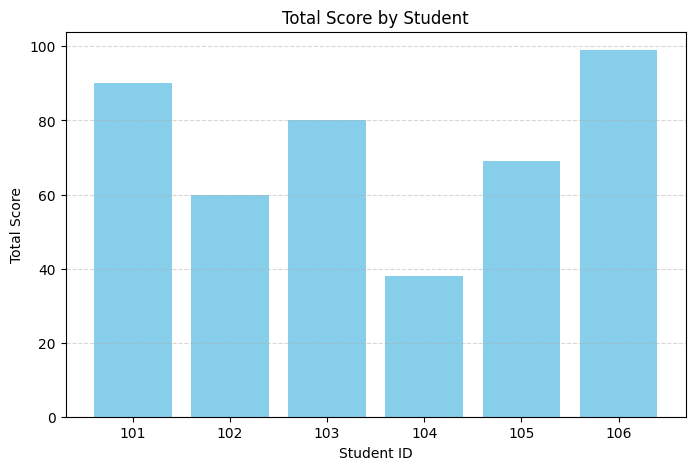

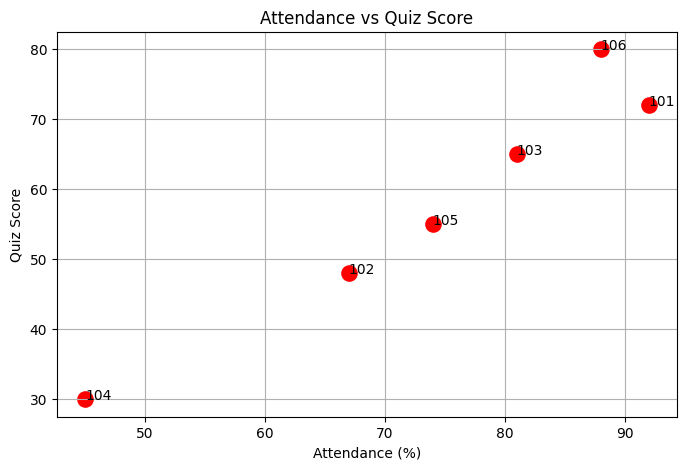

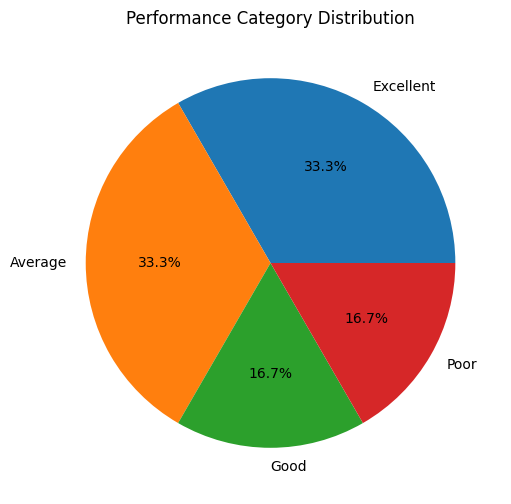

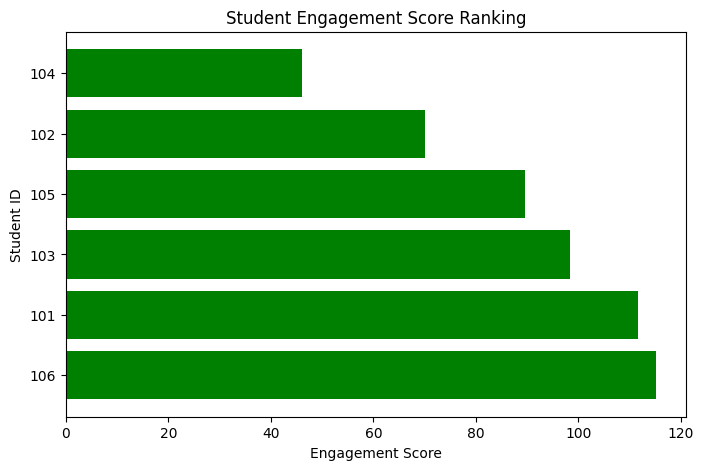

In [ ]:
df["total_score"] = df["assignment_score"] + df["quiz_score"]

# Attendance Status
df["attendance_status"] = np.where(
    df["attendance_percent"] >= 75,
    "Regular",
    "Irregular"
)

# Performance Category
def performance(score):
    if score >= 90:
        return "Excellent"
    elif score >= 75:
        return "Good"
    elif score >= 60:
        return "Average"
    else:
        return "Poor"

df["performance"] = df["total_score"].apply(performance)

# Engagement Score
df["engagement_score"] = (
    df["attendance_percent"] * 0.4 +
    df["quiz_score"] * 0.4 +
    df["assignment_score"] * 2 +
    df["lab_completed"].astype(int) * 10
)

print(df)

# ---------------------------
# Visualization 1:
# Total Score by Student
# ---------------------------
plt.figure(figsize=(8,5))
plt.bar(df["student_id"].astype(str), df["total_score"], color='skyblue')
plt.title("Total Score by Student")
plt.xlabel("Student ID")
plt.ylabel("Total Score")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# ---------------------------
# Visualization 2:
# Attendance vs Quiz Score
# ---------------------------
plt.figure(figsize=(8,5))
plt.scatter(
    df["attendance_percent"],
    df["quiz_score"],
    s=120,
    c='red'
)

for i in range(len(df)):
    plt.annotate(
        df["student_id"][i],
        (df["attendance_percent"][i], df["quiz_score"][i])
    )

plt.title("Attendance vs Quiz Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Quiz Score")
plt.grid(True)
plt.show()

# ---------------------------
# Visualization 3:
# Performance Distribution
# ---------------------------
plt.figure(figsize=(6,6))
df["performance"].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Performance Category Distribution")
plt.ylabel("")
plt.show()

# ---------------------------
# Visualization 4:
# Engagement Score Ranking
# ---------------------------
df_sorted = df.sort_values(
    by="engagement_score",
    ascending=False
)

plt.figure(figsize=(8,5))
plt.barh(
    df_sorted["student_id"].astype(str),
    df_sorted["engagement_score"],
    color='green'
)
plt.title("Student Engagement Score Ranking")
plt.xlabel("Engagement Score")
plt.ylabel("Student ID")
plt.show()

2ND WEEK WORK (15-JUNE-2026 TO 17-JUNE-2026):

In [20]:
subjects = ["Python", "Math", "AI", "Data"]

In [21]:
print(subjects[0])

Python


In [22]:
print(subjects[-1])

Data


In [1]:
marks = 72

if marks>=40:
  print("Pass")
else:
  print("Fail")

Pass


In [2]:
x=int(input("enter"))
if(x>=80):
  print("distinction")
elif(x>=40 and x<80):
  print("pass")
else:
  print("fail")
if(x%2==0):
  print("even")
else:
  print("odd")

enter67
pass
odd


In [3]:
age=int(input("enter"))
if(age<=13 and age>0):
  print("child")
elif(age>13 and age<=19):
  print("teenager")
else:
  print("adult")

enter56
adult


In [4]:
students = [
    {"name": "Palak", "marks": 92, "attendance": 95, "lab_assignment": True},
    {"name": "Akshat", "marks": 75, "attendance": 85, "lab_assignment": True},
    {"name": "Rishi", "marks": 58, "attendance": 60, "lab_assignment": True},
    {"name": "Aman", "marks": 88, "attendance": 90, "lab_assignment": False},
    {"name": "Ananya", "marks": 35, "attendance": 80, "lab_assignment": True}
]

for student in students:
    if student["lab_assignment"] == False:
        result = "Lab Assignment Not Submitted"
    elif student["attendance"] < 75:
        result = "Low Attendance"
    elif student["marks"] >= 70:
        result = "Distinction"
    elif student["marks"] >= 40:
        result = "Pass"
    else:
        result = "Fail"

    print(student["name"], "-", result)

Palak - Distinction
Akshat - Distinction
Rishi - Low Attendance
Aman - Lab Assignment Not Submitted
Ananya - Fail


In [5]:
 def st(x):
  if x<40:
    return 'Fail'
  else:
    return 'Pass'
print(st(89))
print(st(33))

Pass
Fail


In [6]:
import numpy as np

In [13]:
import pandas as pd

In [7]:
import numpy as np
marks = np.array([
    [78, 91, 55],
    [72, 40, 88]
])
print("Highest marks", marks.max())


Highest marks 91


In [8]:
from google.colab import files
uploaded=files.upload()

Saving session4_dummy_students_data.csv.xls to session4_dummy_students_data.csv.xls


In [15]:


df = pd.read_csv("session4_dummy_students_data.csv.xls")
print(df)

    student_id    name  age     city  math  science  english  \
0          101   Aarav   16   Mumbai    78       84       69   
1          102    Diya   16    Delhi    91       88       94   
2          103   Kabir   17  Mathura    55       61       58   
3          104   Meera   16    Noida    72       79       81   
4          105   Rohan   17   Mumbai    40       52       47   
5          106    Sara   16    Delhi    88       93       90   
6          107  Ishaan   17  Mathura    64       70       66   
7          108  Ananya   16    Noida    95       92       89   
8          109  Vivaan   17   Mumbai    48       57       51   
9          110    Tara   16    Delhi    83       76       85   
10         111   Arjun   17  Mathura    67       63       72   
11         112   Nisha   16    Noida    74       81       79   
12         113     Dev   17   Mumbai    35       45       42   
13         114   Priya   16    Delhi    89       86       91   
14         115   Kunal   17  Mathura    

In [16]:
science_score=df["science"].to_numpy()
math_score=df["math"].to_numpy()
english_score=df["english"].to_numpy()
avg=(math_score.sum()+science_score.sum()+english_score.sum())/3
print(avg )

1427.0


In [17]:
ft=df[df['attendance_percent']<75]
print(ft[['name','attendance_percent']])

      name  attendance_percent
4    Rohan                  68
8   Vivaan                  71
12     Dev                  62
18    Yash                  66


In [20]:



# 2. Create average column
average = (
    df["math"] +
    df["science"] +
    df["english"]
) / 3

# 3. Create result column
result = np.where(average >= 40, "Pass", "Fail")


# 4. Print class average
print("Class Average:")
print(np.mean(average))


# 5. Print highest and lowest average
print("\nHighest Average:")
print(np.max(average))

print("\nLowest Average:")
print(np.min(average))





ft=df[df['attendance_percent']<75]
print(ft[['name','attendance_percent']])


# 8. Students with fewer than 6 assignments
print("\nAssignments Below 6:")
low_assignments_students = df[df["assignments_submitted"] < 6]
for name in low_assignments_students["name"]:
    print(name)


# 9. Save final report
final = np.column_stack((
    df["name"].values,
    average,
    result
))

np.savetxt(
    "session4_student_report.csv",
    final,
    delimiter=",",
    fmt="%s",
    header="name,average,result",
    comments=""
)

print("\nSaved as session4_student_report.csv")

Class Average:
71.35000000000001

Highest Average:
92.66666666666667

Lowest Average:
40.666666666666664
      name  attendance_percent
4    Rohan                  68
8   Vivaan                  71
12     Dev                  62
18    Yash                  66

Assignments Below 6:
Rohan
Dev
Yash

Saved as session4_student_report.csv


•	Find the average final_project_score.


In [23]:
# Calculate the average of the 'final_project_score' column
average_final_project_score = df['final_project_score'].mean()
print(f"The average final project score is: {average_final_project_score:.2f}")

The average final project score is: 73.65


•	Find students with study_hours_per_week greater than 8.


In [24]:
# Filter students with 'study_hours_per_week' greater than 8
high_study_hours_students = df[df['study_hours_per_week'] > 8]

print("Students with more than 8 study hours per week:")
for index, row in high_study_hours_students.iterrows():
    print(f"- {row['name']} (Study Hours: {row['study_hours_per_week']})")

Students with more than 8 study hours per week:
- Diya (Study Hours: 11)
- Sara (Study Hours: 10)
- Ananya (Study Hours: 12)
- Tara (Study Hours: 9)
- Priya (Study Hours: 10)
- Riya (Study Hours: 13)
- Aditi (Study Hours: 9)


•	Compare average marks of Mumbai students and Pune students.

In [25]:
# Calculate total average marks for each student
df['total_subject_marks'] = (df['math'] + df['science'] + df['english']) / 3

# Filter students by city
mumbai_students = df[df['city'] == 'Mumbai']
delhi_students = df[df['city'] == 'Delhi']

# Calculate average marks for Mumbai students
if not mumbai_students.empty:
    avg_marks_mumbai = mumbai_students['total_subject_marks'].mean()
    print(f"Average marks for Mumbai students: {avg_marks_mumbai:.2f}")
else:
    print("No students found from Mumbai.")

# Calculate average marks for Delhi students
if not delhi_students.empty:
    avg_marks_delhi = delhi_students['total_subject_marks'].mean()
    print(f"Average marks for Delhi students: {avg_marks_delhi:.2f}")
else:
    print("No students found from Delhi.")

# Compare
if not mumbai_students.empty and not delhi_students.empty:
    if avg_marks_mumbai > avg_marks_delhi:
        print("Mumbai students have a higher average mark.")
    elif avg_marks_delhi > avg_marks_mumbai:
        print("Delhi students have a higher average mark.")
    else:
        print("Mumbai and Delhi students have the same average mark.")

Average marks for Mumbai students: 56.20
Average marks for Delhi students: 86.80
Delhi students have a higher average mark.


•	Create a new column called performance_level.


In [26]:
# Define a function to categorize performance level
def get_performance_level(score):
    if score >= 85:
        return 'Excellent'
    elif score >= 70:
        return 'Good'
    elif score >= 50:
        return 'Average'
    else:
        return 'Needs Improvement'

# Apply the function to create the 'performance_level' column
df['performance_level'] = df['total_subject_marks'].apply(get_performance_level)

print(df[['name', 'total_subject_marks', 'performance_level']].head())

    name  total_subject_marks  performance_level
0  Aarav            77.000000               Good
1   Diya            91.000000          Excellent
2  Kabir            58.000000            Average
3  Meera            77.333333               Good
4  Rohan            46.333333  Needs Improvement


•	Save only selected columns to a new CSV.

In [27]:
# Select relevant columns to save
selected_columns = [
    'student_id',
    'name',
    'city',
    'attendance_percent',
    'total_subject_marks',
    'performance_level',
    'final_project_score'
]

df_report = df[selected_columns]

# Save to a new CSV file
report_filename = 'student_performance_report.csv'
df_report.to_csv(report_filename, index=False)

print(f"Selected columns saved to '{report_filename}'")
print("Head of the new report DataFrame:")
print(df_report.head())

Selected columns saved to 'student_performance_report.csv'
Head of the new report DataFrame:
   student_id   name     city  attendance_percent  total_subject_marks  \
0         101  Aarav   Mumbai                  92            77.000000   
1         102   Diya    Delhi                  96            91.000000   
2         103  Kabir  Mathura                  75            58.000000   
3         104  Meera    Noida                  89            77.333333   
4         105  Rohan   Mumbai                  68            46.333333   

   performance_level  final_project_score  
0               Good                   82  
1          Excellent                   93  
2            Average                   60  
3               Good                   78  
4  Needs Improvement                   45  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url="https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df=pd.read_csv(url)


print(df.head())
print(df.shape)
print(df.columns)
print(df.info())


       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan  1952   8425333.0      Asia   28.801  779.445314
1  Afghanistan  1957   9240934.0      Asia   30.332  820.853030
2  Afghanistan  1962  10267083.0      Asia   31.997  853.100710
3  Afghanistan  1967  11537966.0      Asia   34.020  836.197138
4  Afghanistan  1972  13079460.0      Asia   36.088  739.981106
(1704, 6)
Index(['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB
None


In [2]:
df = df.rename(columns={
    "lifeExp": "life_expectancy",
    "pop": "population",
    "gdpPercap": "gdp_per_capita"
})

print(df.head())
print(df.columns)


       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106
Index(['country', 'year', 'population', 'continent', 'life_expectancy',
       'gdp_per_capita'],
      dtype='object')


In [3]:
print("Missing values in each column:")
print(df.isna().sum)

print("Number of duplicate rows:", df.duplicated().sum())

Missing values in each column:
<bound method DataFrame.sum of       country   year  population  continent  life_expectancy  gdp_per_capita
0       False  False       False      False            False           False
1       False  False       False      False            False           False
2       False  False       False      False            False           False
3       False  False       False      False            False           False
4       False  False       False      False            False           False
...       ...    ...         ...        ...              ...             ...
1699    False  False       False      False            False           False
1700    False  False       False      False            False           False
1701    False  False       False      False            False           False
1702    False  False       False      False            False           False
1703    False  False       False      False            False           False

[1704 rows x 

In [4]:
df_clean = df.copy()

# Remove exact duplicate rows if any
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates()

# Strip extra spaces from text columns
for col in ["country", "continent"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Ensure expected data types
df_clean["year"] = df_clean["year"].astype(int)
df_clean["population"] = df_clean["population"].astype(float)
df_clean["life_expectancy"] = df_clean["life_expectancy"].astype(float)
df_clean["gdp_per_capita"] = df_clean["gdp_per_capita"].astype(float)

print(df_clean.dtypes)
print(df_clean.head())



country             object
year                 int64
population         float64
continent           object
life_expectancy    float64
gdp_per_capita     float64
dtype: object
       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106


In [5]:
dirty_demo = df_clean.head(12).copy()

# Deliberately introduce missing values for teaching practice
dirty_demo.loc[2, "life_expectancy"] = np.nan
dirty_demo.loc[5, "gdp_per_capita"] = np.nan

print(dirty_demo)
print(dirty_demo.isna().sum())

# Fill missing numerical values using median
clean_demo = dirty_demo.copy()
clean_demo["life_expectancy"] = clean_demo["life_expectancy"].fillna(clean_demo["life_expectancy"].median())
clean_demo["gdp_per_capita"] = clean_demo["gdp_per_capita"].fillna(clean_demo["gdp_per_capita"].median())

print(clean_demo.isna().sum())
print(clean_demo)


        country  year  population continent  life_expectancy  gdp_per_capita
0   Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1   Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2   Afghanistan  1962  10267083.0      Asia              NaN      853.100710
3   Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4   Afghanistan  1972  13079460.0      Asia           36.088      739.981106
5   Afghanistan  1977  14880372.0      Asia           38.438             NaN
6   Afghanistan  1982  12881816.0      Asia           39.854      978.011439
7   Afghanistan  1987  13867957.0      Asia           40.822      852.395945
8   Afghanistan  1992  16317921.0      Asia           41.674      649.341395
9   Afghanistan  1997  22227415.0      Asia           41.763      635.341351
10  Afghanistan  2002  25268405.0      Asia           42.129      726.734055
11  Afghanistan  2007  31889923.0      Asia           43.828      974.580338

In [6]:
min_year = df['year'].min()
max_year = df['year'].max()
print(f"The year range in the dataset is from {min_year} to {max_year}.")

The year range in the dataset is from 1952 to 2007.


In [9]:

# Number of countries
num_countries = df['country'].nunique()
print("Number of Countries:", num_countries)

# Number of continents
num_continents = df['continent'].nunique()
print("Number of Continents:", num_continents)

Number of Countries: 142
Number of Continents: 5


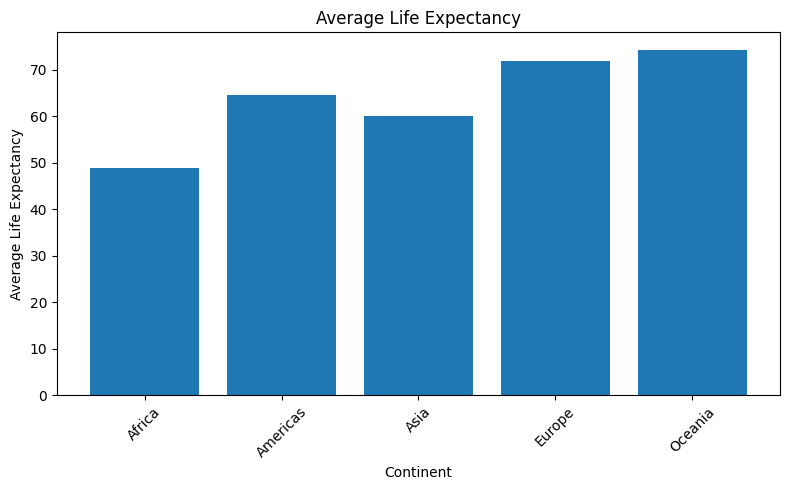

In [11]:
continent_life = df.groupby('continent')['life_expectancy'].mean()

plt.figure(figsize=(8, 5))

plt.bar(continent_life.index, continent_life.values)

plt.title("Average Life Expectancy")
plt.xlabel("Continent")
plt.ylabel("Average Life Expectancy")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

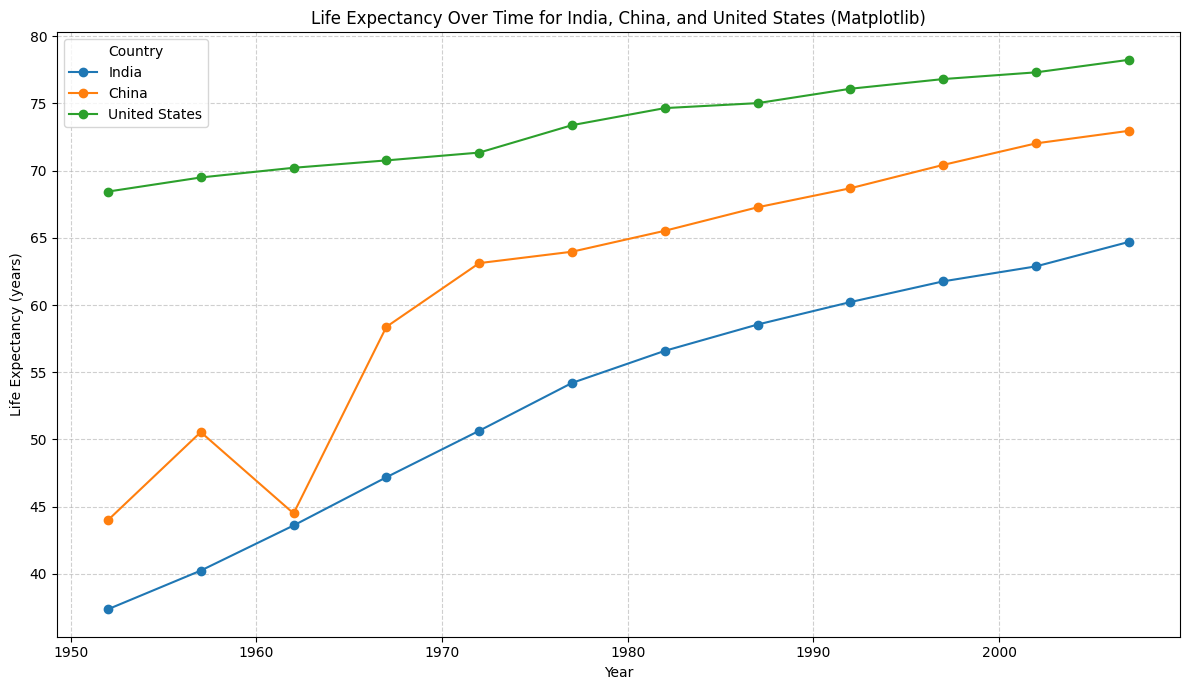

In [18]:
import matplotlib.pyplot as plt

# Filter data for India, China, and United States
countries_to_plot = ['India', 'China', 'United States']
df_filtered = df[df['country'].isin(countries_to_plot)]

plt.figure(figsize=(12, 7))

# Plot life expectancy for each country
for country in countries_to_plot:
    country_data = df_filtered[df_filtered['country'] == country]
    plt.plot(country_data['year'], country_data['life_expectancy'], marker='o', label=country)

plt.title('Life Expectancy Over Time for India, China, and United States (Matplotlib)')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (years)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Country')
plt.tight_layout()
plt.show()

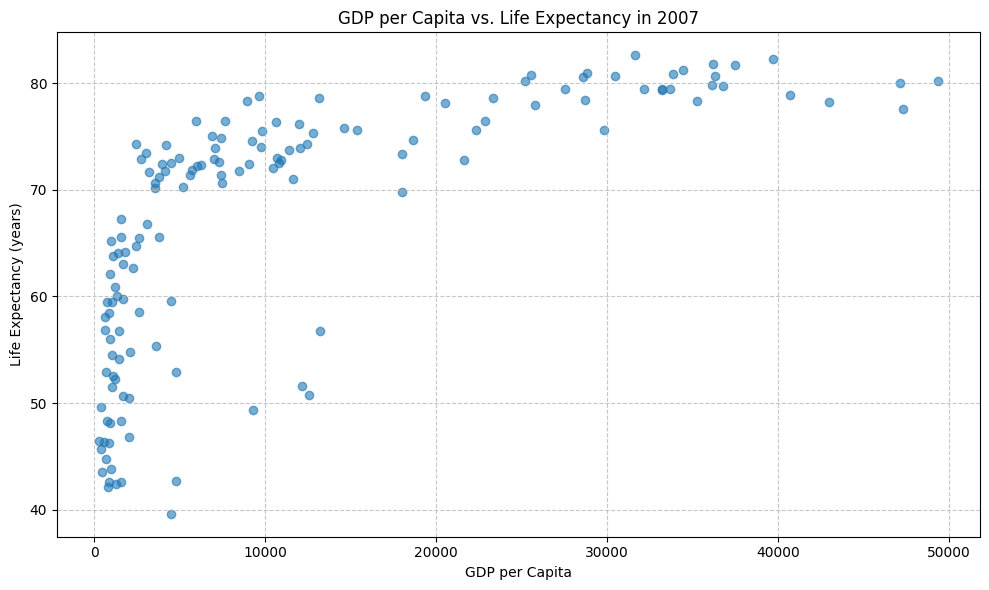

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Reload the gapminder data to ensure 'df' refers to the correct dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df_gapminder = pd.read_csv(url)

# Rename columns as done previously for consistency
df_gapminder = df_gapminder.rename(columns={
    "lifeExp": "life_expectancy",
    "pop": "population",
    "gdpPercap": "gdp_per_capita"
})
df_2007 = df_gapminder[df_gapminder['year'] == 2007]

plt.figure(figsize=(10, 6))
plt.scatter(df_2007['gdp_per_capita'], df_2007['life_expectancy'], alpha=0.6)

plt.title('GDP per Capita vs. Life Expectancy in 2007')
plt.xlabel('GDP per Capita')
plt.ylabel('Life Expectancy (years)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()